<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/alfagift_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Alfagift Google App Review - Exploratory Data Analysis**

**1. Install Necessary Packages**


In [52]:
!pip install pandas matplotlib seaborn nltk
!pip install Sastrawi

**2. Import Required Libraries**

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
from wordcloud import WordCloud

nltk.download('stopwords')
from nltk.corpus import stopwords

nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
from google.colab import files
uploaded = files.upload()
df_alfagiftrev = pd.read_csv(list(uploaded.keys())[0])
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)
df_alfagiftrev['content'] = df_alfagiftrev['content'].str.lower()
df_alfagiftrev.head()

Saving df_alfagiftrev_preprocessing (3).csv to df_alfagiftrev_preprocessing (3) (1).csv


,content,score,sentiment_polarity,review_length,sentiment_subjective,sentiment_rating,at,content_cleaned,wordCount,wordCount_after_stopwords
0,parah sesi anda telah selesai ngapain coba kel...,1,0.0,77,0.0,Negative,2026-03-30 13:39:27,parah sesi selesai ngapain coba keluara gunaka,13,7
1,tolong pihak alfamart sediakan jual rokok,2,0.0,46,0.0,Negative,2026-03-30 13:33:37,tolong alfamart sediakan jual rokok,6,5
2,ini gaada menu cancel orderan kah,3,0.0,36,0.0,Neutral,2026-03-30 13:11:09,gaada menu cancel orderan kah,6,5
3,percuma ada chat aplikasi kalo gapernah dibaca...,1,0.0,195,0.0,Negative,2026-03-30 12:57:09,chat aplikasi gapernah dibaca mending klik idm...,35,24
4,udah nyaman eh alfamart nya pindah jadi jauh s...,2,0.0,89,0.0,Negative,2026-03-30 12:46:39,udah nyaman eh alfamart pindah 1 jam pembayara...,16,11


**3. Data Overview**

In [55]:
# Convert 'at' column to datetime format
df_alfagiftrev['at'] = pd.to_datetime(df_alfagiftrev['at'])

# Display dataset info and first few rows
df_alfagiftrev.info()
df_alfagiftrev.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170732 entries, 0 to 170731
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   content                    170732 non-null  object        
 1   score                      170732 non-null  int64         
 2   sentiment_polarity         170732 non-null  float64       
 3   review_length              170732 non-null  int64         
 4   sentiment_subjective       170732 non-null  float64       
 5   sentiment_rating           170732 non-null  object        
 6   at                         170732 non-null  datetime64[ns]
 7   content_cleaned            165795 non-null  object        
 8   wordCount                  170732 non-null  int64         
 9   wordCount_after_stopwords  170732 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 13.0+ MB


,content,score,sentiment_polarity,review_length,sentiment_subjective,sentiment_rating,at,content_cleaned,wordCount,wordCount_after_stopwords
0,parah sesi anda telah selesai ngapain coba kel...,1,0.0,77,0.0,Negative,2026-03-30 13:39:27,parah sesi selesai ngapain coba keluara gunaka,13,7
1,tolong pihak alfamart sediakan jual rokok,2,0.0,46,0.0,Negative,2026-03-30 13:33:37,tolong alfamart sediakan jual rokok,6,5
2,ini gaada menu cancel orderan kah,3,0.0,36,0.0,Neutral,2026-03-30 13:11:09,gaada menu cancel orderan kah,6,5
3,percuma ada chat aplikasi kalo gapernah dibaca...,1,0.0,195,0.0,Negative,2026-03-30 12:57:09,chat aplikasi gapernah dibaca mending klik idm...,35,24
4,udah nyaman eh alfamart nya pindah jadi jauh s...,2,0.0,89,0.0,Negative,2026-03-30 12:46:39,udah nyaman eh alfamart pindah 1 jam pembayara...,16,11


**4. Missing Values Analysis**

In [56]:
missing_values = df_alfagiftrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
content                         0
score                           0
sentiment_polarity              0
review_length                   0
sentiment_subjective            0
sentiment_rating                0
at                              0
content_cleaned              4937
wordCount                       0
wordCount_after_stopwords       0
dtype: int64


**5. Review Score Distribution**

/tmp/ipykernel_13280/2666859909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_alfagiftrev['score'], palette="viridis")


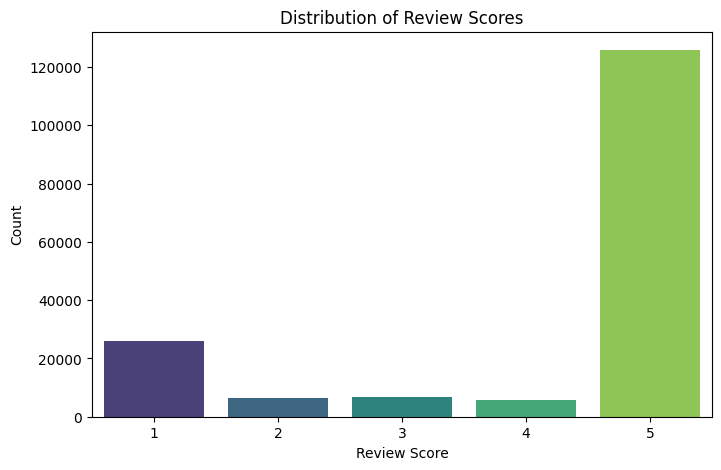

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_alfagiftrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

**6. Review Trends Over Time**

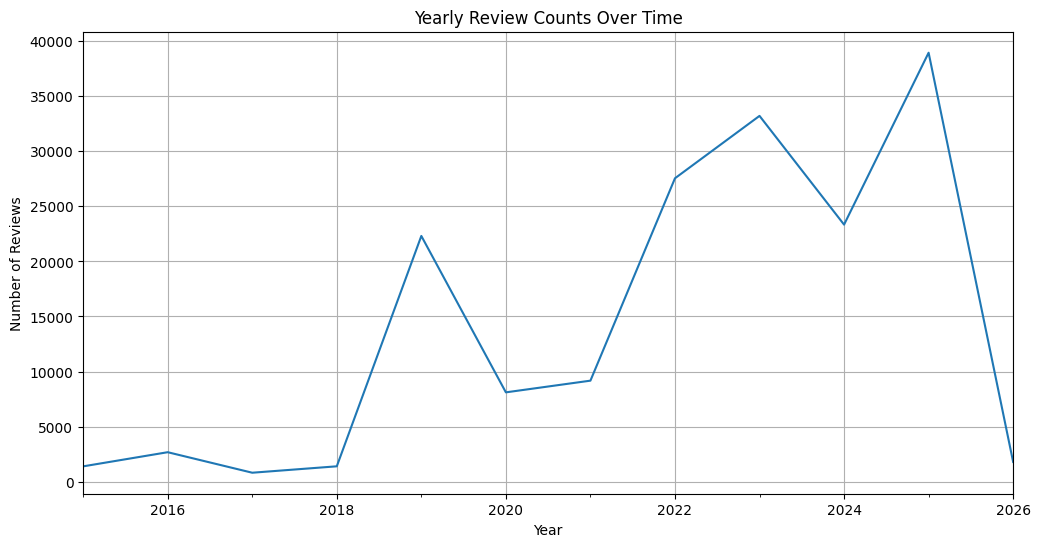

In [58]:
# Extract review year
df_alfagiftrev['review_year'] = df_alfagiftrev['at'].dt.to_period('Y')
review_trend = df_alfagiftrev.groupby('review_year').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Yearly Review Counts Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

**7.Most Frequent Words**

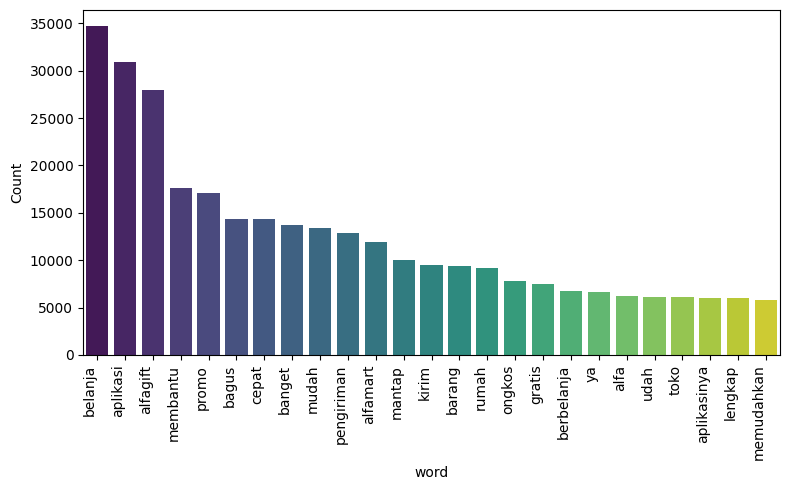

In [59]:
def freq_words(x, terms = 25):
  # Drop NaN values and ensure all elements are strings before joining
  all_words = ' '.join([str(text) for text in x.dropna()])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top `terms` most frequent words, which controls the number of words on the x-axis
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(8,5))
  ax = sns.barplot(data=d, x= "word", y = "count", hue="word", legend=False, palette="viridis")
  ax.set(ylabel = 'Count')
  plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

freq_words(df_alfagiftrev['content_cleaned'])

**Length Distribution**

Histogram ini menunjukkan frekuensi kemunculan review berdasarkan jumlah karakternya. Garis putus-putus merah menunjukkan rata-rata panjang review,

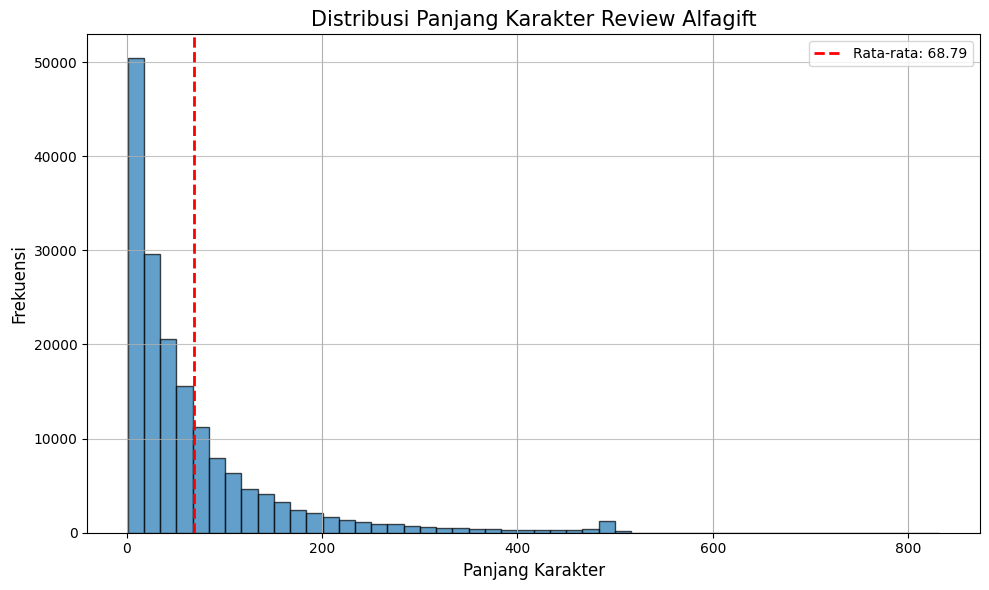

In [60]:
plt.figure(figsize=(10, 6))
df_alfagiftrev['review_length'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.axvline(df_alfagiftrev['review_length'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Rata-rata: {df_alfagiftrev['review_length'].mean():.2f}")
plt.title("Distribusi Panjang Karakter Review Alfagift", fontsize=15)
plt.xlabel("Panjang Karakter", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


**Polarity Distribution**

Distribusi Sentiment Polarity menunjukkan sebaran nilai polaritas sentimen dalam ulasan. Nilai mendekati 1 menunjukkan sentimen positif, mendekati -1 menunjukkan sentimen negatif, dan mendekati 0 menunjukkan sentimen netral. Dari plot tersebut, kita bisa melihat apakah ulasan cenderung positif, negatif, atau netral secara keseluruhan.

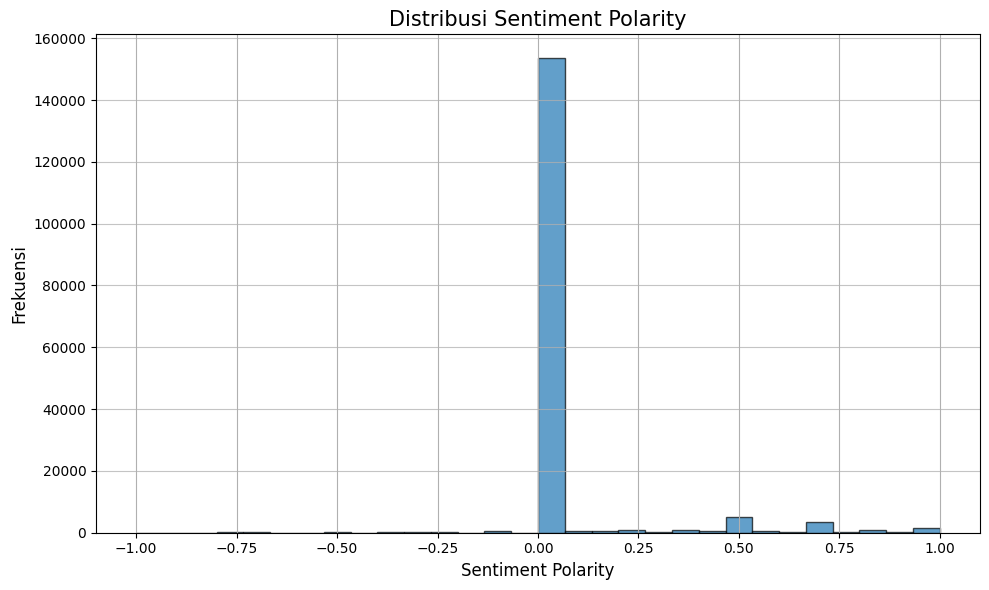

In [61]:
plt.figure(figsize=(10, 6))
df_alfagiftrev['sentiment_polarity'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribusi Sentiment Polarity", fontsize=15)
plt.xlabel("Sentiment Polarity", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Subjectivity Distribution**

Distribusi Sentiment Subjectivity menunjukkan tingkat objektivitas atau subjektivitas ulasan. Nilai mendekati 1 berarti ulasan sangat subjektif (berdasarkan opini pribadi), sementara nilai mendekati 0 berarti ulasan lebih objektif (berdasarkan fakta). Plot ini membantu kita memahami apakah ulasan Alfagift lebih banyak berisi opini atau fakta.

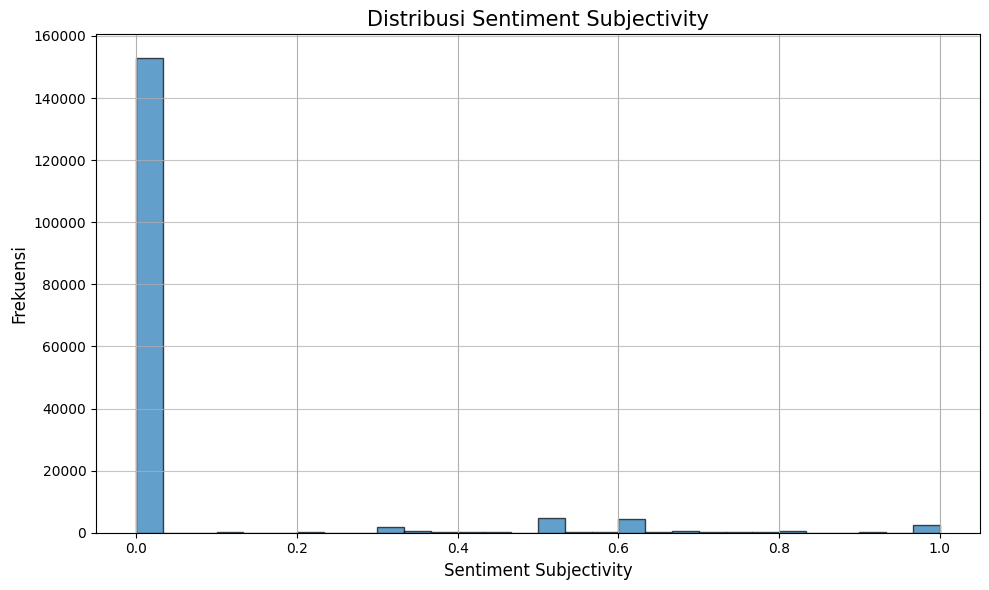

In [62]:

plt.figure(figsize=(10, 6))
df_alfagiftrev['sentiment_subjective'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribusi Sentiment Subjectivity", fontsize=15)
plt.xlabel("Sentiment Subjectivity", fontsize=12)
plt.ylabel("Frekuensi", fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Workcloud**

Representasi visual dari frekuensi kata dalam suatu teks. Dalam WordCloud, kata-kata yang muncul lebih sering dalam teks akan ditampilkan dengan ukuran font yang lebih besar dan/atau warna yang lebih menonjol, sementara kata-kata yang kurang sering muncul akan ditampilkan dengan ukuran lebih kecil.

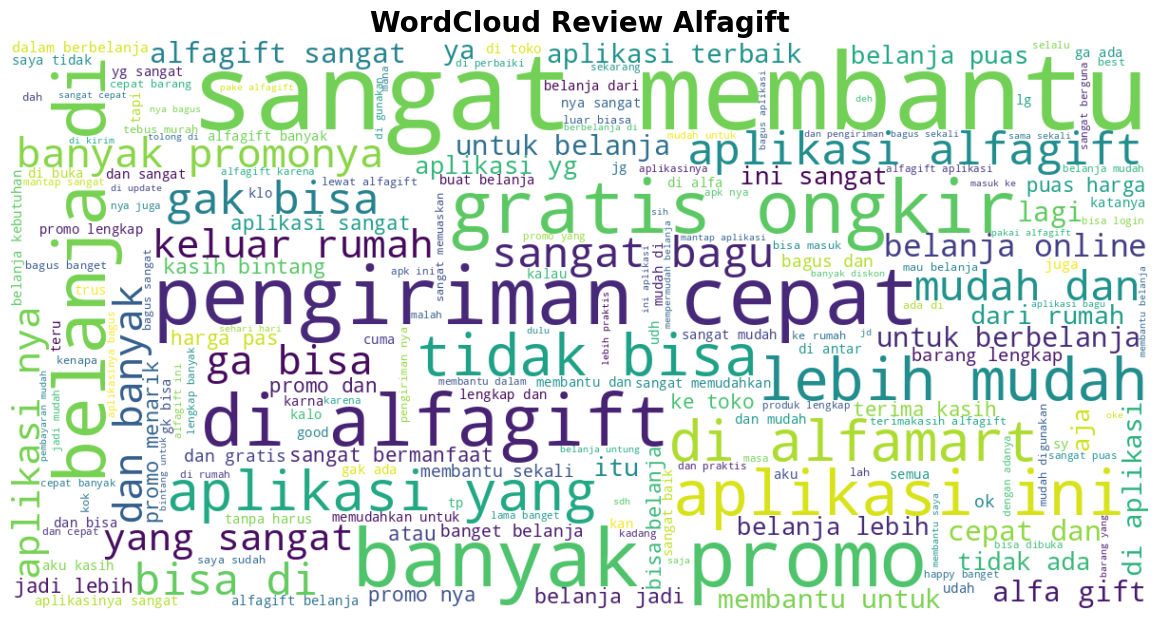

In [63]:
text = " ".join(df_alfagiftrev['content'].dropna())

wordcloud = WordCloud(width=1200, height=600,
                      background_color='white',
                      colormap='viridis',
                      max_words=200,
                      min_font_size=10).generate(text)

plt.figure(figsize=(12, 6)) # Increase figure size
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Review Alfagift", fontsize=20, weight='bold') # Make title more prominent
plt.tight_layout(pad=0) # Adjust layout for better fit
plt.show()

In [64]:


# ======================
# 11. INSIGHT OTOMATIS
# ======================
print("\n=== QUICK INSIGHT ===")

print(f"Total data: {len(df_alfagiftrev)}")
print(f"Rata-rata panjang review: {df_alfagiftrev['review_length'].mean():.2f}")

print("\nDistribusi rating:")
print(df_alfagiftrev['score'].value_counts(normalize=True)*100)

print("\nRata-rata sentiment polarity:")
print(df_alfagiftrev['sentiment_polarity'].mean())

print("\nRata-rata subjectivity:")
print(df_alfagiftrev['sentiment_subjective'].mean())


=== QUICK INSIGHT ===
Total data: 170732
Rata-rata panjang review: 68.79

Distribusi rating:
score
5    73.698545
1    15.314059
3     3.914322
2     3.682379
4     3.390694
Name: proportion, dtype: float64

Rata-rata sentiment polarity:
0.04856612488206381

Rata-rata subjectivity:
0.06079609138891378
